# **EXP A - 01: ConstLW**

## **0. Setup**

In [80]:
# Load packages
using Revise
using NeuralParam
using Plots
using CairoMakie

In [7]:
# Define experiments and general settings
EXP = "exp_A"

OUTPUT_FORMS  = ["direct", "linear", "planck"]
COLORS_OF = [JL_BLUE, JL_GREEN, JL_RED];

In [8]:
# Define offline runs

# Series
SER_OFF = "01_CLW_offline"

# Schemes / Rollouts
OFF = ["offline_$(name)" for name in OUTPUT_FORMS];

In [9]:
# Define offline runs

# Series
SER_ON = "02_CLW_online"

# Schemes / Rollouts
ON_D = ["online_direct_s$j" for j in 1:3]
ON_L = ["online_linear_s$j" for j in 1:3]
ON_P = ["online_planck_s$j" for j in 1:3];

### 0.1. Reference Sanity Check

In [5]:
# Reference sanity check
ref_weather = collect_rollouts(EXP, SER_OFF, ["0_OBLW"]; leg = :weather).var"0_OBLW"
test_reference(ref_weather)

┌ Info: Reference reproduced exactly: every probe and IC is zero at the first lead time.
└ @ NeuralParam c:\Code\NeuralParam.jl\src\evaluation\evaluate_rollout.jl:1008


Row,probe,ic,max_first,exact
,String,Int64,Float32,Bool
1,T,1,0.0,true
2,olw,1,0.0,true
3,slwd,1,0.0,true
4,T,2,0.0,true
5,olw,2,0.0,true
6,slwd,2,0.0,true


In [6]:
# Reference sanity check
ref_climate = collect_rollouts(EXP, SER_OFF, ["0_OBLW"]; leg = :climate).var"0_OBLW"
test_reference(ref_climate)

┌ Info: Reference reproduced exactly: every probe and IC is zero at the first lead time.
└ @ NeuralParam c:\Code\NeuralParam.jl\src\evaluation\evaluate_rollout.jl:1008


Row,probe,ic,max_first,exact
,String,Int64,Float32,Bool
1,T,1,0.0,true
2,olw,1,0.0,true
3,slwd,1,0.0,true
4,T,2,0.0,true
5,olw,2,0.0,true
6,slwd,2,0.0,true
7,T,3,0.0,true
8,olw,3,0.0,true
9,slwd,3,0.0,true


## **1. Training**

### 1.1. Offline

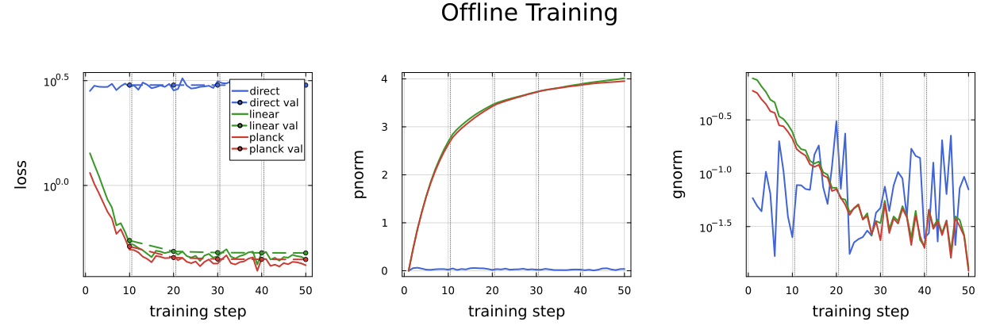

In [7]:
# Load runs
runs_off = collect_runs(EXP, SER_OFF, OFF);

# Define colors and labels
colors = COLORS_OF
labels = OUTPUT_FORMS;

# Plot training results for offline runs
plot_training(runs_off; labels, colors, ncols=3, plot_config = (; plot_title = "Offline Training"))

### 1.2. Online

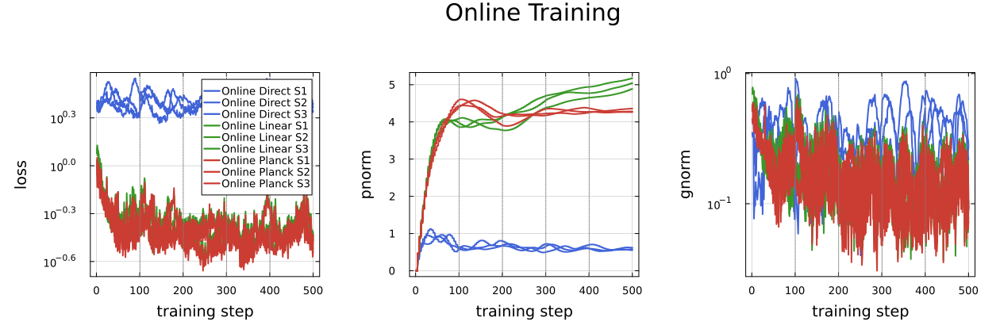

In [8]:
# Load runs
runs_on = collect_runs(EXP, SER_ON, [ON_D... , ON_L... , ON_P...]);

# Define colors and labels
colors = [fill(JL_BLUE, 3)..., fill(JL_GREEN, 3)..., fill(JL_RED, 3)...];

# Define labels
labels = ["Online Direct S1", "Online Direct S2", "Online Direct S3",
          "Online Linear S1", "Online Linear S2", "Online Linear S3",
          "Online Planck S1", "Online Planck S2", "Online Planck S3"];

# Plot training results for offline runs
plot_training(runs_on; labels, colors, ncols=3, plot_config = (; plot_title = "Online Training"))

## **2. Skill Plane**

┌ Warning: not drawn (non-finite score, e.g. every climate trajectory died in the scored window): ["offline_linear", "offline_planck"]
└ @ NeuralParam c:\Code\NeuralParam.jl\src\evaluation\evaluate_rollout.jl:1355


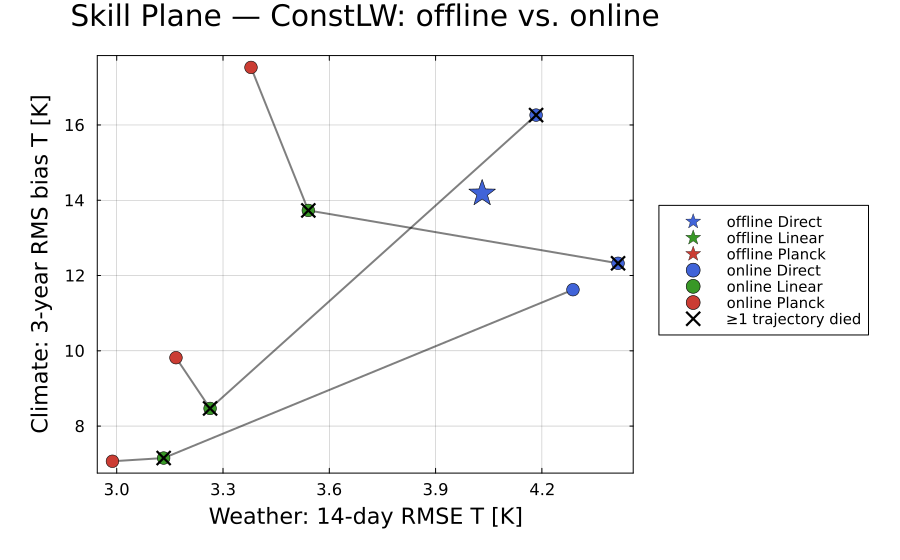

In [40]:
# Prepare skill plane plot

# Define units
off = ["offline_$(n)"      for n in ("direct","linear","planck")]
on  = ["online_$(n)_s$(j)" for n in ("direct","linear","planck") for j in 1:3]

# Collect weather and climate rollouts
w = merge(collect_rollouts(EXP, SER_OFF, OFF; leg = :weather),
          collect_rollouts(EXP, SER_ON, [ON_D..., ON_L..., ON_P...];  leg = :weather))
c = merge(collect_rollouts(EXP, SER_OFF, OFF; leg = :climate),
          collect_rollouts(EXP, SER_ON,  [ON_D..., ON_L..., ON_P...];  leg = :climate))

# Create skill table
df = skill_table(w, c);

# Define styles and grouping
style = (;
    offline_direct   = (; color = JL_BLUE,  shape = :star,   size = 14, label = "offline Direct", group = :d),
    offline_linear   = (; color = JL_GREEN, shape = :star,   size = 14, label = "offline Linear", group = :l),
    offline_planck   = (; color = JL_RED,   shape = :star,   size = 14, label = "offline Planck", group = :p),


    online_direct_s1 = (; color = JL_BLUE,  shape = :circle,  label = "online Direct", group = :s1),
    online_direct_s2 = (; color = JL_BLUE,  shape = :circle,  label = "online Direct", group = :s2),
    online_direct_s3 = (; color = JL_BLUE,  shape = :circle, label = "online Direct", group = :s3),

    online_linear_s1 = (; color = JL_GREEN, shape = :circle,  label = "online Linear", group = :s1),
    online_linear_s2 = (; color = JL_GREEN, shape = :circle,  label = "online Linear", group = :s2),
    online_linear_s3 = (; color = JL_GREEN, shape = :circle, label = "online Linear", group = :s3),

    online_planck_s1 = (; color = JL_RED,   shape = :circle,  label = "online Planck", group = :s1),
    online_planck_s2 = (; color = JL_RED,   shape = :circle,  label = "online Planck", group = :s2),
    online_planck_s3 = (; color = JL_RED,   shape = :circle, label = "online Planck", group = :s3),
)

# Plot skill plane
p = plot_skill_plane(df; style, trace_color = :black, equal_axes = false,
        title = "Skill Plane — ConstLW: offline vs. online",
        xlabel = "Weather: 14-day RMSE T [K]",
        ylabel = "Climate: 3-year RMS bias T [K]",
)

In [41]:
# Save plot
Plots.savefig(p, "figures/01_ConstLW_skillplane.png");

## **3. Weather**

### 3.1. Offline

#### 3.1.1. ZeroLW Baseline

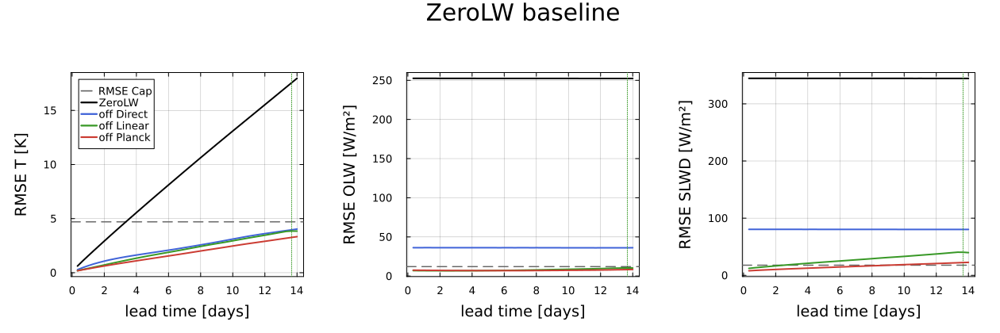

In [82]:
# Define units
units = ["0_ZeroLW", OFF...]

# Collect rollouts
w = collect_rollouts(EXP, SER_OFF, units; leg = :weather);

# Define labels and colors
labels = ["ZeroLW", "off Direct", "off Linear", "off Planck"]
colors = [:black, COLORS_OF...];

# Plot weather
p = plot_weather(w, :rmse; labels, colors, 
    cap = (; T = 4.69975965312033, olw = 12.057038271354907, slwd = 17.732078475374166),
    cap_label = "RMSE Cap",
    band = false, plot_config = (; plot_title = "ZeroLW baseline"), ncols=3)

In [84]:
# Save plot
Plots.savefig(p, "figures/01_ZeroLW_baseline.png");

#### 3.1.2. Output Forms

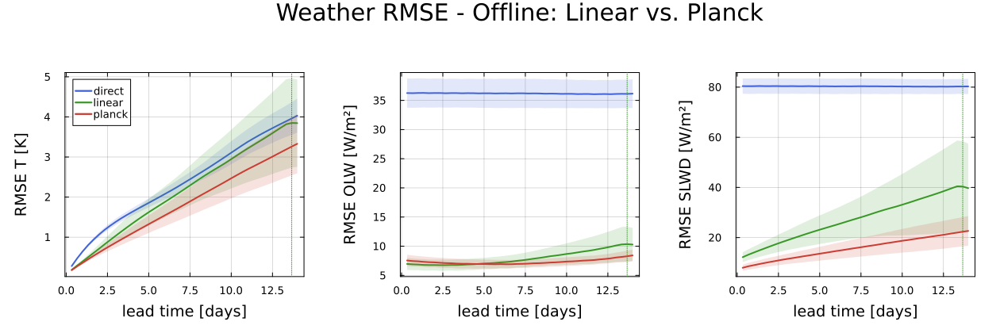

In [84]:
# Define units
units = ["offline_direct", "offline_linear", "offline_planck"]

# Collect rollouts
w = collect_rollouts(EXP, SER_OFF, units; leg = :weather);

# Define labels and colors
labels = ["direct", "linear", "planck"]
colors = [JL_BLUE, JL_GREEN, JL_RED]

# Plot weather: RMSE
plot_weather(w, :rmse; labels, colors, plot_config = (; plot_title = "Weather RMSE - Offline: Linear vs. Planck"))

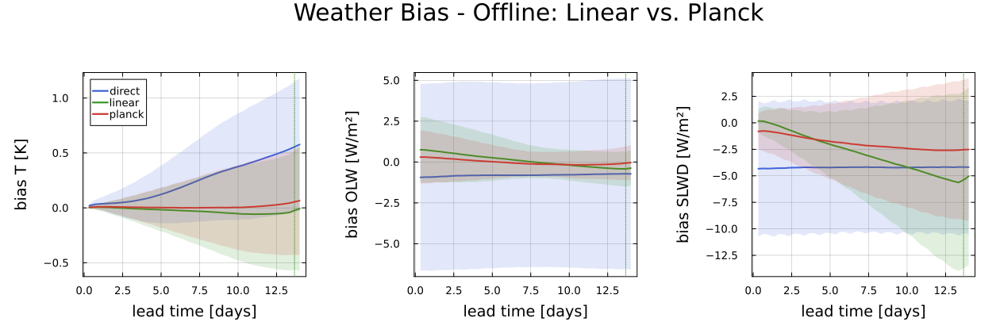

In [85]:
# Plot weather: bias
plot_weather(w, :bias; labels, colors, plot_config = (; plot_title = "Weather Bias - Offline: Linear vs. Planck"))

### 3.2. Online

#### 3.2.1. Seeding

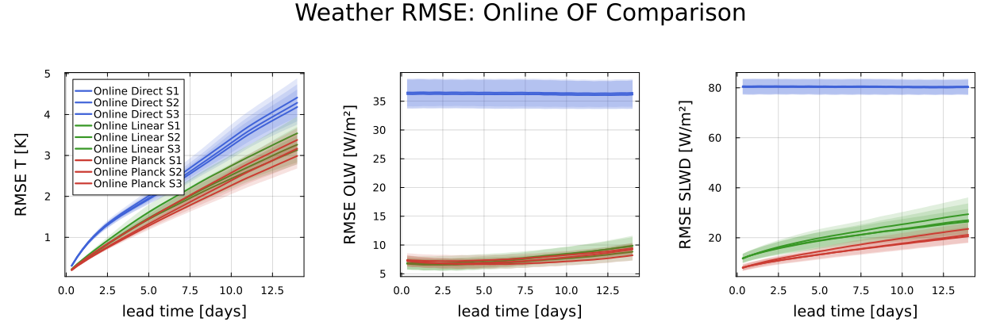

In [86]:
# Collect rollouts
units = [ON_D..., ON_L..., ON_P...]

# Collect rollouts
w = collect_rollouts(EXP, SER_ON, units; leg = :weather);

# Define colors and labels
colors = [fill(JL_BLUE, 3)..., fill(JL_GREEN, 3)..., fill(JL_RED, 3)...];

# Define labels
labels = ["Online Direct S1", "Online Direct S2", "Online Direct S3",
          "Online Linear S1", "Online Linear S2", "Online Linear S3",
          "Online Planck S1", "Online Planck S2", "Online Planck S3"];

# Plot weather
plot_weather(w, :rmse; labels, colors, plot_config = (; plot_title = "Weather RMSE: Online OF Comparison"))

### 3.3. Offline vs. Online

#### 3.3.1. Direct

In [95]:
# Collect rollouts
w_off = collect_rollouts(EXP, SER_OFF, ["offline_direct"]; leg = :weather)
w_on = collect_rollouts(EXP, SER_ON, ON_D; leg = :weather)

w = merge(w_on, w_off)


# Define labels and colors
labels = ["on S1", "on S2", "on S3", "off"]
colors = [JL_BLUE, JL_BLUE, JL_BLUE, :black];

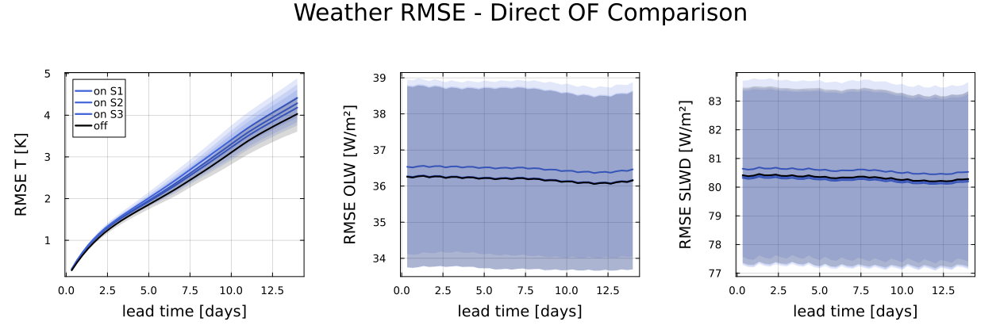

In [96]:
# Plot weather
plot_weather(w, :rmse; labels, colors, plot_config = (; plot_title = "Weather RMSE - Direct OF Comparison"))

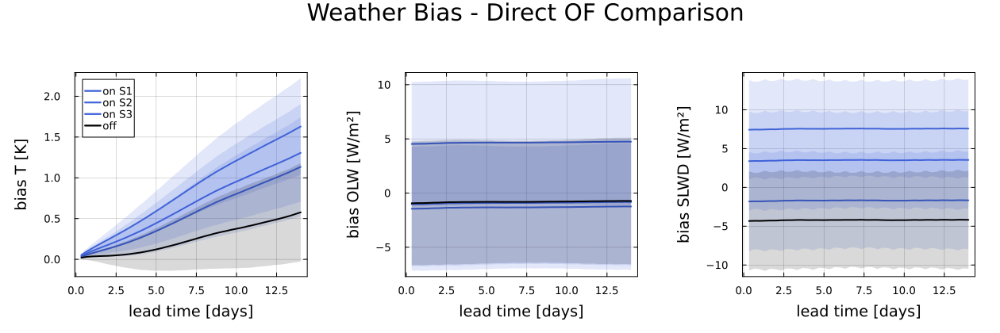

In [97]:
# Plot weather
plot_weather(w, :bias; labels, colors, plot_config = (; plot_title = "Weather Bias - Direct OF Comparison"))

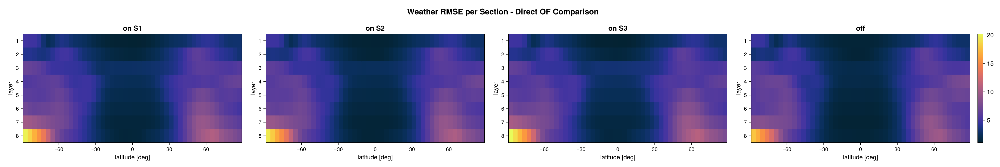

In [98]:
# Plot weather
plot_weather_sections(w, :T, 14; metric = :rmse, labels, suptitle = "Weather RMSE per Section - Direct OF Comparison")

#### 3.3.2. Linear

In [99]:
# Collect rollouts
w_off = collect_rollouts(EXP, SER_OFF, ["offline_linear"]; leg = :weather)
w_on = collect_rollouts(EXP, SER_ON, ON_L; leg = :weather)

w = merge(w_on, w_off)


# Define labels and colors
labels = ["on S1", "on S2", "on S3", "off"]
colors = [JL_GREEN, JL_GREEN, JL_GREEN, :black];

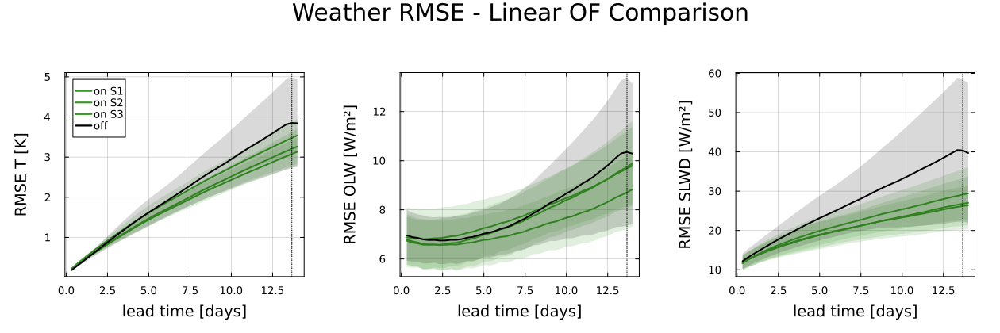

In [94]:
# Plot weather
plot_weather(w, :rmse; labels, colors, plot_config = (; plot_title = "Weather RMSE - Linear OF Comparison"))

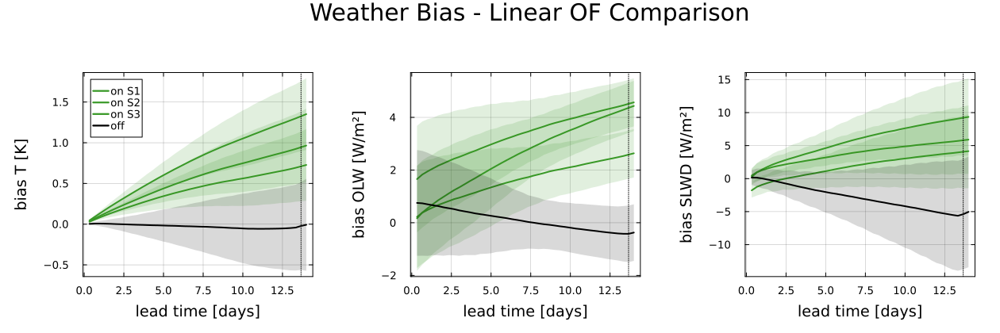

In [100]:
# Plot weather
plot_weather(w, :bias; labels, colors, plot_config = (; plot_title = "Weather Bias - Linear OF Comparison"))

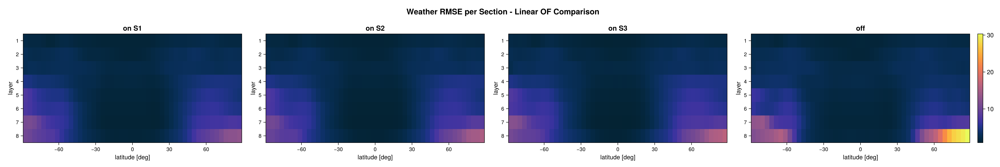

In [101]:
plot_weather_sections(w, :T, 14; metric = :rmse, labels, suptitle = "Weather RMSE per Section - Linear OF Comparison")

#### 3.3.3. Planck

In [102]:
# Collect rollouts
w_off = collect_rollouts(EXP, SER_OFF, ["offline_planck"]; leg = :weather)
w_on = collect_rollouts(EXP, SER_ON, ON_P; leg = :weather)

w = merge(w_on, w_off)


# Define labels and colors
labels = ["on S1", "on S2", "on S3", "off"]
colors = [JL_RED, JL_RED, JL_RED, :black];

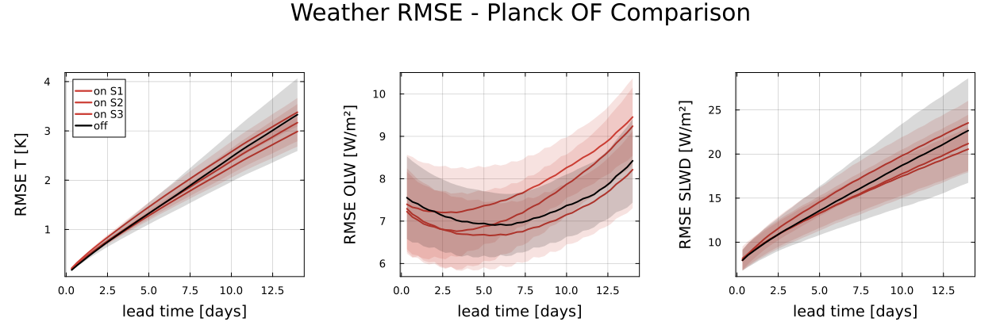

In [103]:
# Plot weather
plot_weather(w, :rmse; labels, colors, plot_config = (; plot_title = "Weather RMSE - Planck OF Comparison"))

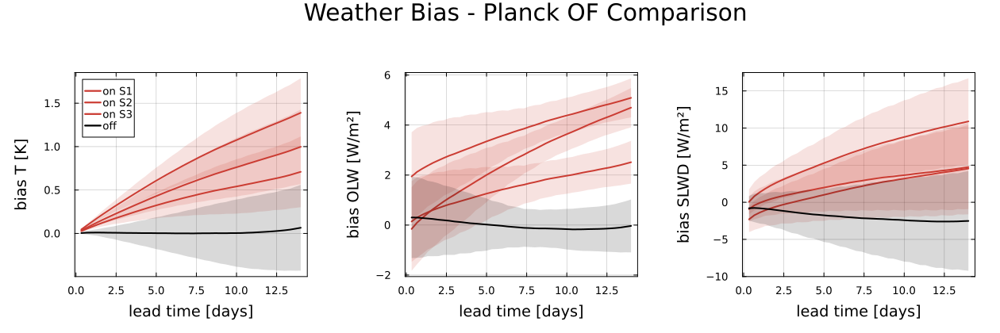

In [104]:
# Plot weather
plot_weather(w, :bias; labels, colors, plot_config = (; plot_title = "Weather Bias - Planck OF Comparison"))

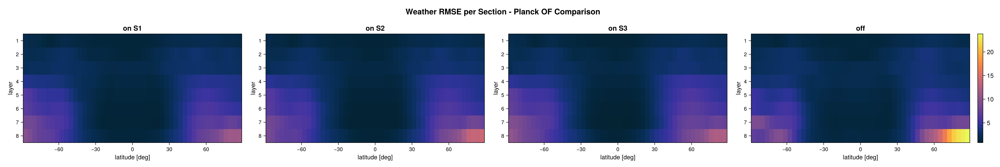

In [105]:
plot_weather_sections(w, :T, 14; metric = :rmse, labels, suptitle = "Weather RMSE per Section - Planck OF Comparison")

## **4. Climate**

### 4.1. Offline

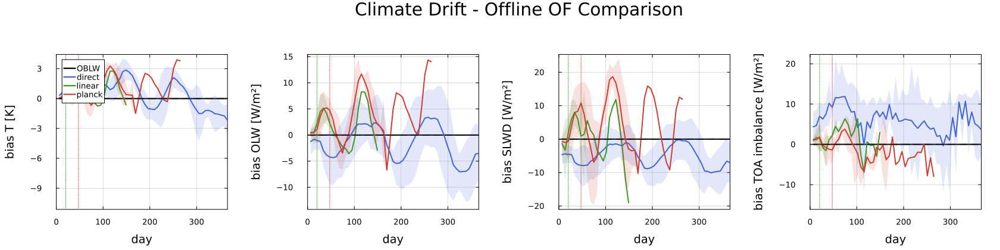

In [ ]:
# Define units
units = ["0_OBLW", OFF...]

# Collect rollouts
c = collect_rollouts(EXP, SER_OFF, units; leg = :climate);

# Define labels and colors
labels = ["OBLW", OUTPUT_FORMS...]
colors = [:black, COLORS_OF...];

# Plot climate
plot_drift(c; labels, colors, plot_config = (; xlims = (0, 366), plot_title = "Climate Drift -- Offline OF Comparison"))

In [107]:
# Create table for survival statistics
sort(climate_table(c), :unit; by = u -> findfirst(==(u), units))

Row,unit,survived,alive,n_traj,drift_T,drift_olw,drift_slwd,rms_T,rms_olw,rms_slwd,drift,rms,pct
,String,Float32,Int64,Int64,Float32,Float32,Float32,Float32,Float32,Float32,Float32,Float32,Float32
1,0_OBLW,1098.0,4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,offline_direct,1098.0,4,4,-5.24015,-1.3818,-4.59304,14.1805,33.3405,78.436,0.352023,1.54771,Inf
3,offline_linear,13.6,0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,offline_planck,40.7,0,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 4.2. Online

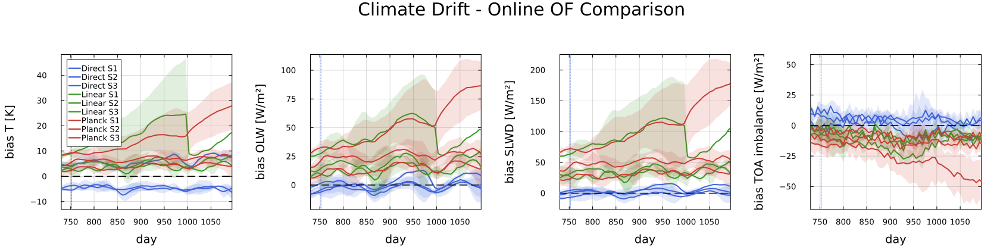

In [109]:
# Collect rollouts
units = [ON_D..., ON_L..., ON_P...]

# Collect rollouts
c = collect_rollouts(EXP, SER_ON, units; leg = :climate);

# Define colors and labels
colors = [fill(JL_BLUE, 3)..., fill(JL_GREEN, 3)..., fill(JL_RED, 3)...];

# Define labels
labels = ["Direct S1", "Direct S2", "Direct S3",
          "Linear S1", "Linear S2", "Linear S3",
          "Planck S1", "Planck S2", "Planck S3"];

# Plot climate
plot_drift(c; labels, colors, plot_config = (; plot_title = "Climate Drift - Online OF Comparison", xlims = (2*365, 3*365)))

In [110]:
# Create table for survival statistics
sort(climate_table(c), :unit; by = u -> findfirst(==(u), units))

Row,unit,survived,alive,n_traj,drift_T,drift_olw,drift_slwd,rms_T,rms_olw,rms_slwd,drift,rms,pct
,String,Float32,Int64,Int64,Float32,Float32,Float32,Float32,Float32,Float32,Float32,Float32,Float32
1,online_direct_s1,1098.0,4,4,-4.47136,-1.89613,3.12303,11.6233,33.3658,78.3636,0.301533,1.45148,75.7
2,online_direct_s2,745.6,2,4,6.03531,3.79063,6.89007,16.2624,33.43,78.4371,0.417801,1.6359,98.1
3,online_direct_s3,291.4,2,4,-4.86481,-1.95544,-2.43064,12.325,34.135,79.1422,0.326521,1.49321,80.8
4,online_linear_s1,40.7,2,4,3.42241,13.1867,30.2452,7.15068,18.6035,48.4905,0.531311,0.867349,5.0
5,online_linear_s2,27.1,2,4,5.35969,19.3668,37.5808,8.46864,23.7766,53.9932,0.74241,1.02814,24.5
6,online_linear_s3,27.1,1,4,15.1453,42.2625,88.7637,13.7292,37.2379,82.5434,1.78297,1.61368,95.4
7,online_planck_s1,1098.0,4,4,3.88909,14.45,31.7339,7.0653,17.8552,44.5908,0.57596,0.825968,0.0
8,online_planck_s2,1098.0,4,4,6.90985,25.6879,50.5403,9.81676,28.5776,60.9329,0.983121,1.19611,44.8
9,online_planck_s3,1098.0,4,4,15.4826,52.4895,109.697,17.5292,54.241,116.234,2.09513,2.23546,170.6


### 4.3. Offline vs. Online

In [64]:
# Collect rollouts
c_off = collect_rollouts(EXP, SER_OFF, ["offline_direct"]; leg = :climate)
c_on = collect_rollouts(EXP, SER_ON, ON_P; leg = :climate)

c = merge(c_off, c_on)


# Define labels and colors
labels = ["offline Direct", "online Planck S1", "online Planck S2", "online Planck S3"]
colors = [JL_BLUE, JL_RED, JL_RED, JL_RED];

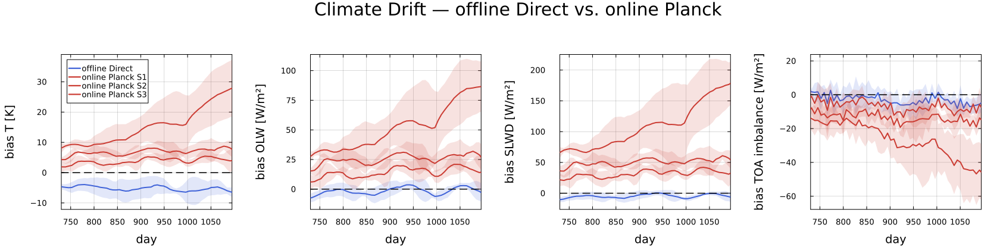

In [65]:
# Plot climate
p = plot_drift(c; labels, colors, plot_config = (; plot_title = "Climate Drift — offline Direct vs. online Planck ", xlims = (2*365, 3*365)))

In [67]:
# Save plot
Plots.savefig(p, "figures/01_Climate_Drift_off_on.png");

In [114]:
# Create table for survival statistics
sort(climate_table(c), :unit; by = u -> something(findfirst(==(u), units), typemax(Int)))

Row,unit,survived,alive,n_traj,drift_T,drift_olw,drift_slwd,rms_T,rms_olw,rms_slwd,drift,rms,pct
,String,Float32,Int64,Int64,Float32,Float32,Float32,Float32,Float32,Float32,Float32,Float32,Float32
1,online_planck_s1,1098.0,4,4,3.88909,14.45,31.7339,7.0653,17.8552,44.5908,0.57596,0.825968,0.0
2,online_planck_s2,1098.0,4,4,6.90985,25.6879,50.5403,9.81676,28.5776,60.9329,0.983121,1.19611,44.8
3,online_planck_s3,1098.0,4,4,15.4826,52.4895,109.697,17.5292,54.241,116.234,2.09513,2.23546,170.6
4,offline_direct,1098.0,4,4,-5.24015,-1.3818,-4.59304,14.1805,33.3405,78.436,0.352023,1.54771,87.4


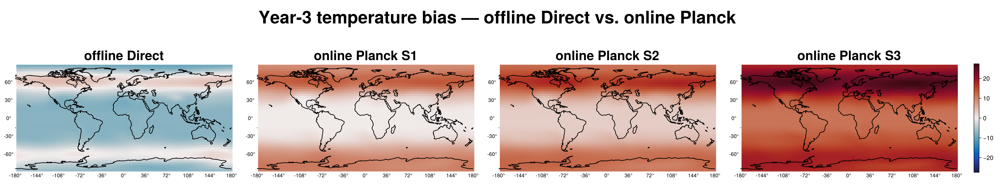

In [75]:
p = plot_climate_maps(c, :T; labels, ncols = 4,
    suptitle = "Year-3 temperature bias — offline Direct vs. online Planck",
    panel_config = merge(HEATMAP_CONFIG, (; titlesize = 30, suptitlesize = 40)))

In [76]:
# Save plot
CairoMakie.save("figures/01_Climate_Map_off_on.png", p);

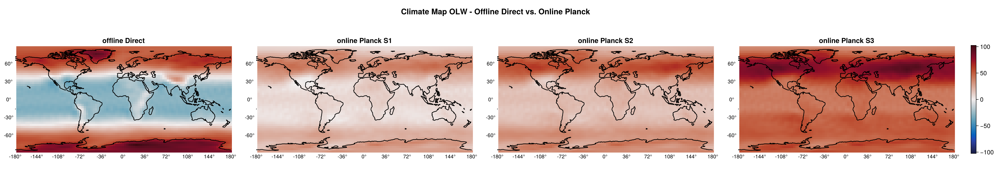

In [68]:
# Plot T bias map
plot_climate_maps(c, :olw; labels, suptitle = "Climate Map OLW - Offline Direct vs. Online Planck")

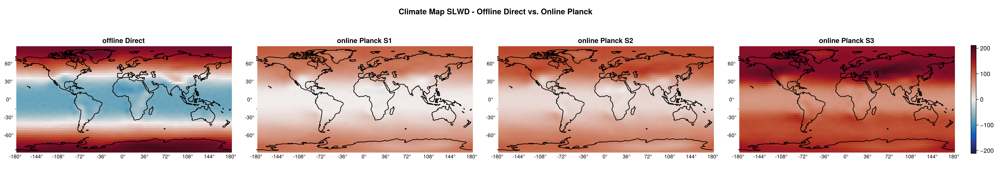

In [69]:
# Plot T bias map
plot_climate_maps(c, :slwd; labels, suptitle = "Climate Map SLWD - Offline Direct vs. Online Planck")